<a href="https://colab.research.google.com/github/Sandyon1top/AI/blob/main/SandipDhakal_Worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Worksheet 3: Modeling the Neuron
### MCP Neurons → Perceptron → Limitations
---

# Task 1 — MCP Neurons: AND and OR Functions

In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with MCP Neuron for two inputs.
    X1, X2 : lists of binary values (same length)
    T       : threshold value
    Returns : state_neuron (list of 0s and 1s)
    """
    assert len(X1) == len(X2)

    # Step 1: element-wise addition of the two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 & 3: compare each sum against threshold T
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2          # AND: both inputs must be 1, so threshold = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

print("\nAND Gate Truth Table:")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result):
    print(f"{x1:>4} {x2:>4} {out:>8}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]

AND Gate Truth Table:
  X1   X2   Output
--------------------
   0    0        0
   0    1        0
   1    0        0
   1    1        1


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with MCP Neuron for two inputs.
    X1, X2 : lists of binary values (same length)
    T       : threshold value
    Returns : state_neuron (list of 0s and 1s)
    """
    assert len(X1) == len(X2)

    # Step 1: element-wise addition of the two input arrays
    summed_inputs = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 & 3: compare each sum against threshold T
    state_neuron = []
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1          # OR: at least one input must be 1, so threshold = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

print("\nOR Gate Truth Table:")
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
print("-" * 20)
for x1, x2, out in zip(X1, X2, result_or):
    print(f"{x1:>4} {x2:>4} {out:>8}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]

OR Gate Truth Table:
  X1   X2   Output
--------------------
   0    0        0
   0    1        1
   1    0        1
   1    1        1


## Written Answers — Task 1

### Question 1: Limitations of MCP Neurons

1. **Fixed hand-crafted threshold** — `T` must be set manually; there is no learning mechanism.
2. **No learnable weights** — all inputs are treated equally; the model cannot learn that some inputs matter more.
3. **Binary inputs only** — real-world continuous data cannot be fed directly.
4. **Binary outputs only** — unsuitable for regression or probabilistic predictions.
5. **Cannot learn from data** — there is no weight-update rule.
6. **Linearly separable problems only** — XOR and similar functions cannot be solved by a single MCP neuron.
7. **Biologically oversimplified** — ignores temporal dynamics, synaptic plasticity, and continuous firing rates.

---

### Question 2: Can XOR be solved with a single MCP Neuron?

**No.** XOR truth table:

| X1 | X2 | XOR |
|:--:|:--:|:---:|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

With `g(X) = X1 + X2`, sums are 0, 1, 1, 2.
- To output 1 for rows 2 and 3 we need `T ≤ 1`.
- But with `T = 1`, row 4 gives sum = 2 ≥ 1 → output **1** (wrong — should be 0).
- No single value of T satisfies all four rows simultaneously.

XOR is **not linearly separable**. It requires at least **two layers** of neurons.

---
# Task 2 — Perceptron: 0 vs 1 Classification

## Step 1 — Load the Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # shape: (n_samples, 784)
y = df_0_1["label"].values                 # shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


**Question 1 — What does the shape of X represent?**
`X.shape` is `(12665, 784)`. The first dimension is the number of images; the second (784) is the number of pixel features per image — each 28×28 MNIST image is flattened to 784 values.

**Question 2 — What does the shape of y represent?**
`y.shape` is `(12665,)` — a 1-D array with the class label (0 or 1) for each image.

## Step 2 — Visualise the Dataset

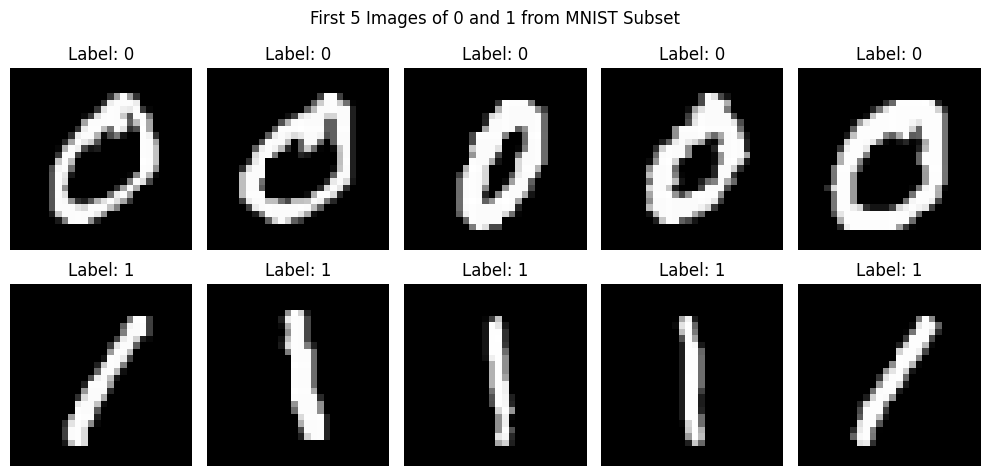

In [5]:
# Separate images by label
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.tight_layout()
    plt.show()

## Step 3 — Initialise Weights and Bias

In [6]:
# Initialize weights and bias
weights       = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape:", weights.shape)
print("Initial bias: ", bias)

Weights shape: (784,)
Initial bias:  0


**Question 3 — What does the weights array represent?**
Each `weights[j]` is the importance assigned to pixel `j`. During training, the perceptron adjusts all 784 values so the weighted sum crosses zero correctly for each class.

**Question 4 — Why initialise weights to zero?**
Zero is a neutral, reproducible starting point. For a single-layer perceptron this is fine — weights diverge from zero as soon as the first error occurs. (For deeper networks, all-zero initialisation causes a symmetry problem, but that does not apply here.)

## Step 4 — Decision (Activation) Function

In [7]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step activation function.

    Parameters:
        X       : numpy array of shape (n_samples, n_features)
        weights : weight vector, shape (n_features,)
        bias    : scalar bias term

    Returns:
        y_pred_all : predicted binary labels (0 or 1)
    """
    predictions = np.dot(X, weights) + bias

    # Step / threshold activation: output 1 if z >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# Quick sanity check before training
sample_pred = decision_function(X[:5], weights, bias)
print("Sample predictions before training:", sample_pred)

Sample predictions before training: [1 1 1 1 1]


## Step 5 — Perceptron Learning Algorithm

In [15]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : feature matrix (n_samples, n_features)
        y             : true labels (n_samples,)
        weights       : initial weight vector (n_features,)
        bias          : initial bias scalar
        learning_rate : step size for weight updates (default 0.1)
        epochs        : max number of passes over the data (default 100)

    Returns:
        weights  : updated weights
        bias     : updated bias
        accuracy : final training accuracy
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True   # assume converged; set False if any update happens

        for i in range(n_samples):
            # Compute weighted sum (net input)
            output = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_hat = 1 if output >= 0 else 0

            # Update weights and bias ONLY if prediction is wrong
            if y_hat != y[i]:
                error   = y[i] - y_hat                            # +1 or -1
                weights = weights + learning_rate * error * X[i]  # weight update
                bias    = bias    + learning_rate * error          # bias update
                convergence_flag = False

        # Report accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            preds = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
            acc   = np.mean(preds == y)
            print(f"Epoch {epoch + 1}: Accuracy = {acc:.4f}")

        # Early stopping: no updates this epoch → converged
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}!")
            break

    # Final training accuracy
    final_preds = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy    = np.mean(final_preds == y)
    return weights, bias, accuracy

**Question 5 — What is the purpose of `output = np.dot(X[i], weights) + bias`?**
It computes the **net input** (pre-activation value) for sample `i`. The result is passed through the step function to produce a 0/1 prediction.

**Question 6 — What happens when the prediction is wrong?**
Error = `y[i] - y_hat` (+1 or −1). Updates:
- `weights += learning_rate × error × X[i]` — nudges each weight toward the correct output.
- `bias    += learning_rate × error` — shifts the decision boundary accordingly.

**Question 7 — Why is final accuracy important, and what do you expect?**
It tells us how well the model separates the two classes. Because 0 and 1 look very different, they are linearly separable in pixel space, so we expect **~100% accuracy**.

## Step 6 — Train the Perceptron

In [9]:
# Re-initialise (fresh start)
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Converged at epoch 13!
The Final Accuracy is:  1.0


## Step 7 — Visualise Misclassified Images

In [10]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualise misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question 8 — What does `misclassified_idx` store and how is it used?**
It is a NumPy array of integer indices where `y_pred != y`. The code uses those indices to fetch, reshape, and display the wrongly classified images alongside their predicted and true labels.

**Question 9 — How do you interpret "All images were correctly classified!"?**
The perceptron found a linear hyperplane in 784-D pixel space that perfectly separates every 0 from every 1. This is consistent with the **Perceptron Convergence Theorem**: if data are linearly separable, the algorithm is guaranteed to converge to zero training error.

---
# Task 3 — Perceptron: 3 vs 5 Classification

In [11]:
#Step 1: Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

# Remap labels to binary: 3 → 0,  5 → 1
y_35_binary = np.where(y_35 == 3, 0, 1)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:  ", y_35.shape)
print("Unique original labels:", np.unique(y_35))

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique original labels: [3 5]


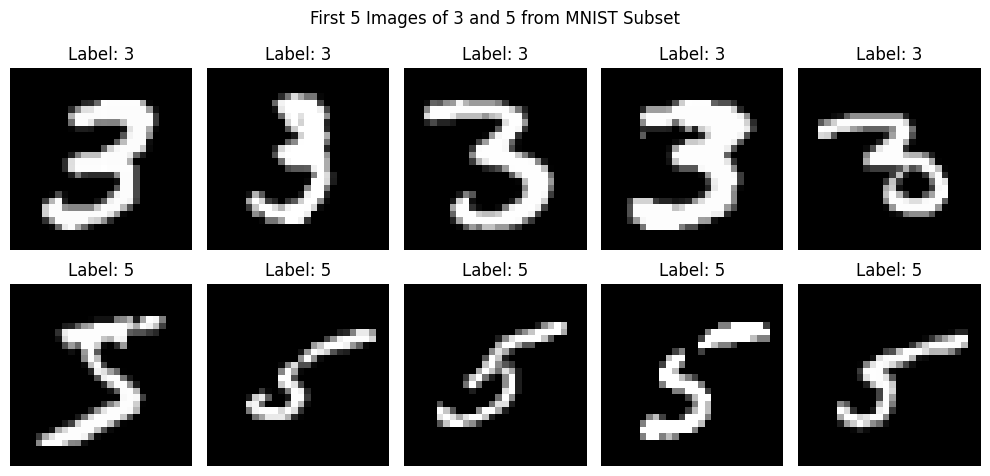

In [12]:
# Step 2: Visualise samples
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.tight_layout()
    plt.show()

In [13]:
# Step 3: Initialise weights and bias
weights_35       = np.zeros(X_35.shape[1])
bias_35          = 0
learning_rate_35 = 0.1
epochs_35        = 100

# Step 4 & 5: Train using the same train_perceptron function
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary,
    weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)

print("The Final Accuracy (3 vs 5) is: ", accuracy_35)

Epoch 10: Accuracy = 0.9613
Epoch 20: Accuracy = 0.9540
Epoch 30: Accuracy = 0.9730
Epoch 40: Accuracy = 0.9730
Epoch 50: Accuracy = 0.9518
Epoch 60: Accuracy = 0.9515
Epoch 70: Accuracy = 0.9770
Epoch 80: Accuracy = 0.9861
Epoch 90: Accuracy = 0.9829
Epoch 100: Accuracy = 0.9869
The Final Accuracy (3 vs 5) is:  0.986866107260124


Final Accuracy (3 vs 5): 0.9869
Number of misclassified samples: 36


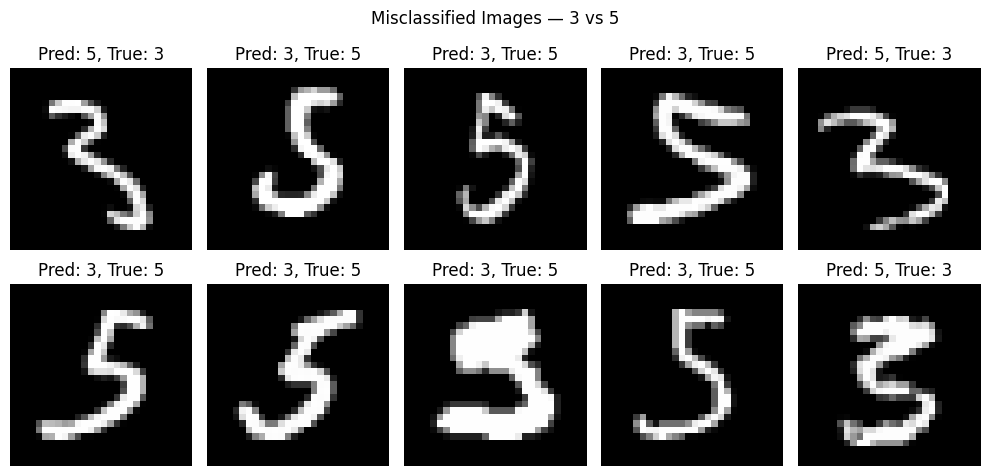

In [14]:
#Step 6: Predictions and misclassified image visualisation
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35      = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]
print(f"Number of misclassified samples: {len(misclassified_idx_35)}")

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        true_label = y_35[idx]
        pred_label = 3 if y_pred_35[idx] == 0 else 5   # map binary back to 3/5
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 3 vs 5")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

## Conclusion — Task 3 (3 vs 5)

**Observation:** The perceptron achieves noticeably lower accuracy on 3 vs 5 than on 0 vs 1. The misclassified images are typically ambiguous digits whose strokes share characteristics of both 3 and 5.

**Why is 3 vs 5 harder?** Both digits share horizontal strokes at the top and bottom with a curved middle section. In raw 784-D pixel space they are much closer together than 0 and 1, making it difficult to draw a single linear decision boundary.

**Core limitation:** The Perceptron Convergence Theorem only guarantees convergence if the data are **linearly separable**. For non-linearly separable problems like 3 vs 5 the perceptron cycles without converging to zero error. A **Multi-Layer Perceptron (MLP)** or **SVM with a non-linear kernel** would be needed to improve performance.